<a href="https://colab.research.google.com/github/gabrieelsky/rps-cnn/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! git clone https://github.com/gabrieelsky/rps-cnn
! mv rps-cnn/* .
! rm -r rps-cnn/ sample_data/

! mkdir -p data/raw
! curl -L -o data/raw/rockpaperscissors.zip https://www.kaggle.com/api/v1/datasets/download/drgfreeman/rockpaperscissors
! unzip -q data/raw/rockpaperscissors.zip -d data/raw/
! rm data/raw/rockpaperscissors.zip
! mkdir saved_models

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from src.data_loader import create_dataloaders, get_class_mapping
from src.models import BaselineCNN, MicroResNet, MediumCNN
from src.train import train_model, run_grid_search
from src.evaluate import evaluate_model
from src.config import *

def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

device = get_device()
print(f"Hardware configuration: Using device '{device}'\n")

class_mapping = get_class_mapping(RAW_DATA_DIR)
num_classes = len(class_mapping)
print(f"{num_classes} classes found: {class_mapping}\n")

Hardware configuration: Using device 'mps'

3 classes found: {'paper': 0, 'rock': 1, 'scissors': 2}



In [ ]:
# Define hyperparameter grid for Stratified K-Fold CV using run_grid_search
param_grid = {
    'lr': [1e-2, 1e-3],
    'batch_size': [16, 32],
    'dropout_rate': [0.3, 0.5],
    'weight_decay': [0, 1e-4],
    'epochs': [20]
}

print('Initiating Stratified K-Fold Grid Search (this may take a while)...')
tuning_results = run_grid_search(MediumCNN, param_grid, None, RAW_DATA_DIR, device=device, num_classes=num_classes, n_splits=3, seed=RANDOM_SEED, patience=3, min_delta=1e-4)
tuning_results.to_csv('saved_models/grid_search_results.csv', index=False)
print('Grid search complete. Top results:')
print(tuning_results.head())

In [ ]:
# Extract best configuration from tuning results
best_config = tuning_results.iloc[0]
# best_config = {
#     'lr': 1e-3,
#     'batch_size': 16,
#     'dropout_rate': 0.5,
#     'weight_decay': 1e-4,
#     'epochs': 20
# }

best_lr = float(best_config['lr'])
best_batch_size = int(best_config['batch_size'])
best_dropout = float(best_config.get('dropout_rate', 0.0))
best_weight_decay = float(best_config.get('weight_decay', 0.0))
best_epochs = int(best_config.get('epochs', 5))
final_epochs = 20  # Train longer for the final run
print(f"Selected best config: lr={best_lr}, batch_size={best_batch_size}, dropout={best_dropout}, weight_decay={best_weight_decay}")

Selected best config: lr=0.001, batch_size=16, dropout=0.5, weight_decay=0.0001


In [ ]:
train_loader, val_loader, test_loader, _ = create_dataloaders(RAW_DATA_DIR, batch_size=best_batch_size)

model = BaselineCNN(num_classes=num_classes, input_shape=(3, IMG_HEIGHT, IMG_WIDTH)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=best_lr, weight_decay=best_weight_decay)

print(f"\nStarting BaselineCNN training with the best parameters...")

model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=final_epochs,
    patience=5,
    min_delta=1e-4
)

print("\nEvaluating BaselineCNN on the test set...")
test_loss, all_preds, all_labels = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    device=device,
    class_mapping=class_mapping,
)

save_path = os.path.join(MODELS_DIR, "baseline_cnn.pth")
torch.save(model.state_dict(), save_path)
print(f"\nBaselineCNN weights successfully saved to {save_path}")

In [ ]:
train_loader, val_loader, test_loader, _ = create_dataloaders(RAW_DATA_DIR, batch_size=best_batch_size)

model = MediumCNN(num_classes=num_classes, input_shape=(3, IMG_HEIGHT, IMG_WIDTH), dropout_rate=best_dropout).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=best_lr, weight_decay=best_weight_decay)

print(f"\nStarting MediumCNN training with the best parameters...")

model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=final_epochs,
    patience=5,
    min_delta=1e-4
)

print("\nEvaluating MediumCNN on the test set...")
test_loss, all_preds, all_labels = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    device=device,
    class_mapping=class_mapping,
)

save_path = os.path.join(MODELS_DIR, "medium_cnn.pth")
torch.save(model.state_dict(), save_path)
print(f"\nMediumCNN weights successfully saved to {save_path}")

<Figure size 640x480 with 0 Axes>

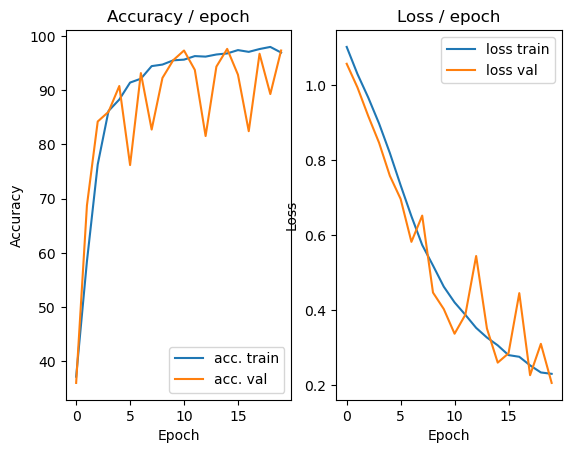


Training complete.

Evaluating MicroResNet on the test set...

Starting final evaluation on test set...

FINAL TEST RESULTS
Average Test Loss: 0.1753

Classification Report:
              precision    recall  f1-score   support

       paper       1.00      0.97      0.99       107
        rock       0.97      0.99      0.98       109
    scissors       0.97      0.98      0.98       113

    accuracy                           0.98       329
   macro avg       0.98      0.98      0.98       329
weighted avg       0.98      0.98      0.98       329



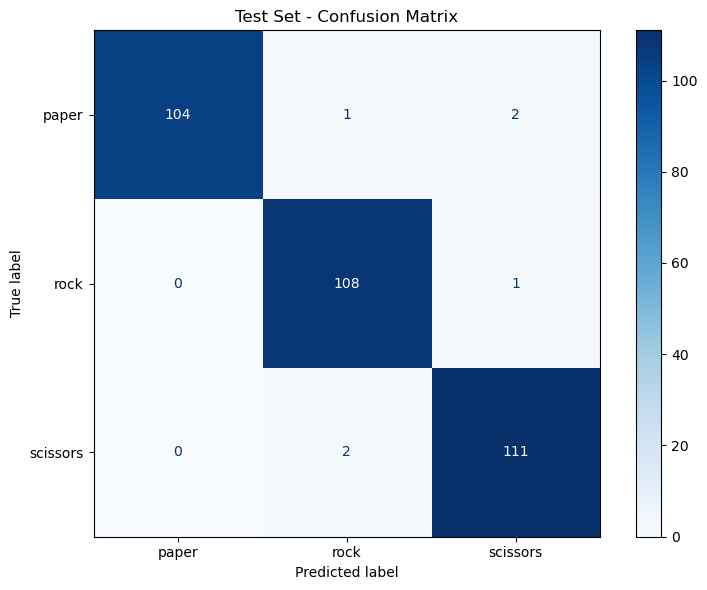


MicroResNet weights successfully saved to /Users/gabriele/repos/rps-cnn/saved_models/micro_resnet.pth


In [4]:
train_loader, val_loader, test_loader, _ = create_dataloaders(RAW_DATA_DIR, batch_size=best_batch_size)

model = MicroResNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=best_lr, weight_decay=best_weight_decay)

print(f"\nStarting MicroResNet training with the best parameters...")

model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=final_epochs,
    patience=5,
    min_delta=1e-4
)

print("\nEvaluating MicroResNet on the test set...")
test_loss, all_preds, all_labels = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    device=device,
    class_mapping=class_mapping,
)

save_path = os.path.join(MODELS_DIR, "micro_resnet.pth")
torch.save(model.state_dict(), save_path)
print(f"\nMicroResNet weights successfully saved to {save_path}")


Starting final evaluation on test set...

FINAL TEST RESULTS
Average Test Loss: 0.1753

Classification Report:
              precision    recall  f1-score   support

       paper       1.00      0.97      0.99       107
        rock       0.97      0.99      0.98       109
    scissors       0.97      0.98      0.98       113

    accuracy                           0.98       329
   macro avg       0.98      0.98      0.98       329
weighted avg       0.98      0.98      0.98       329



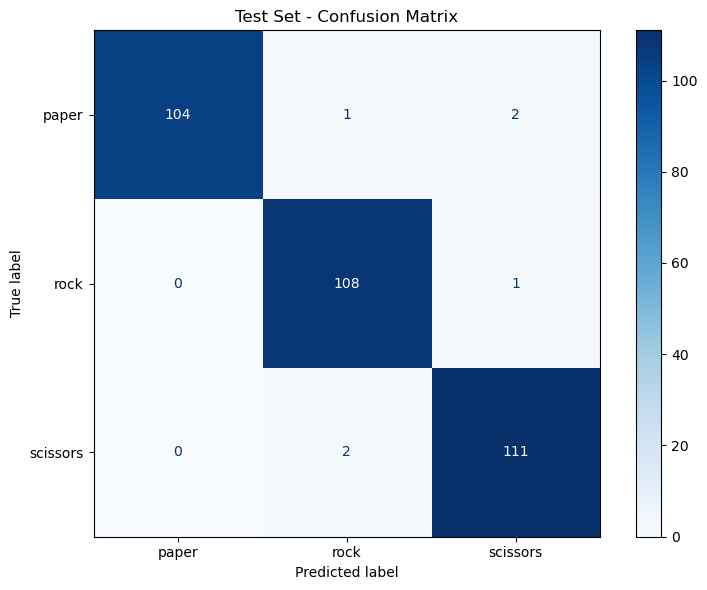


Evaluation-only run completed. Test loss: 0.1753

Misclassified examples (prediction -> ground truth):


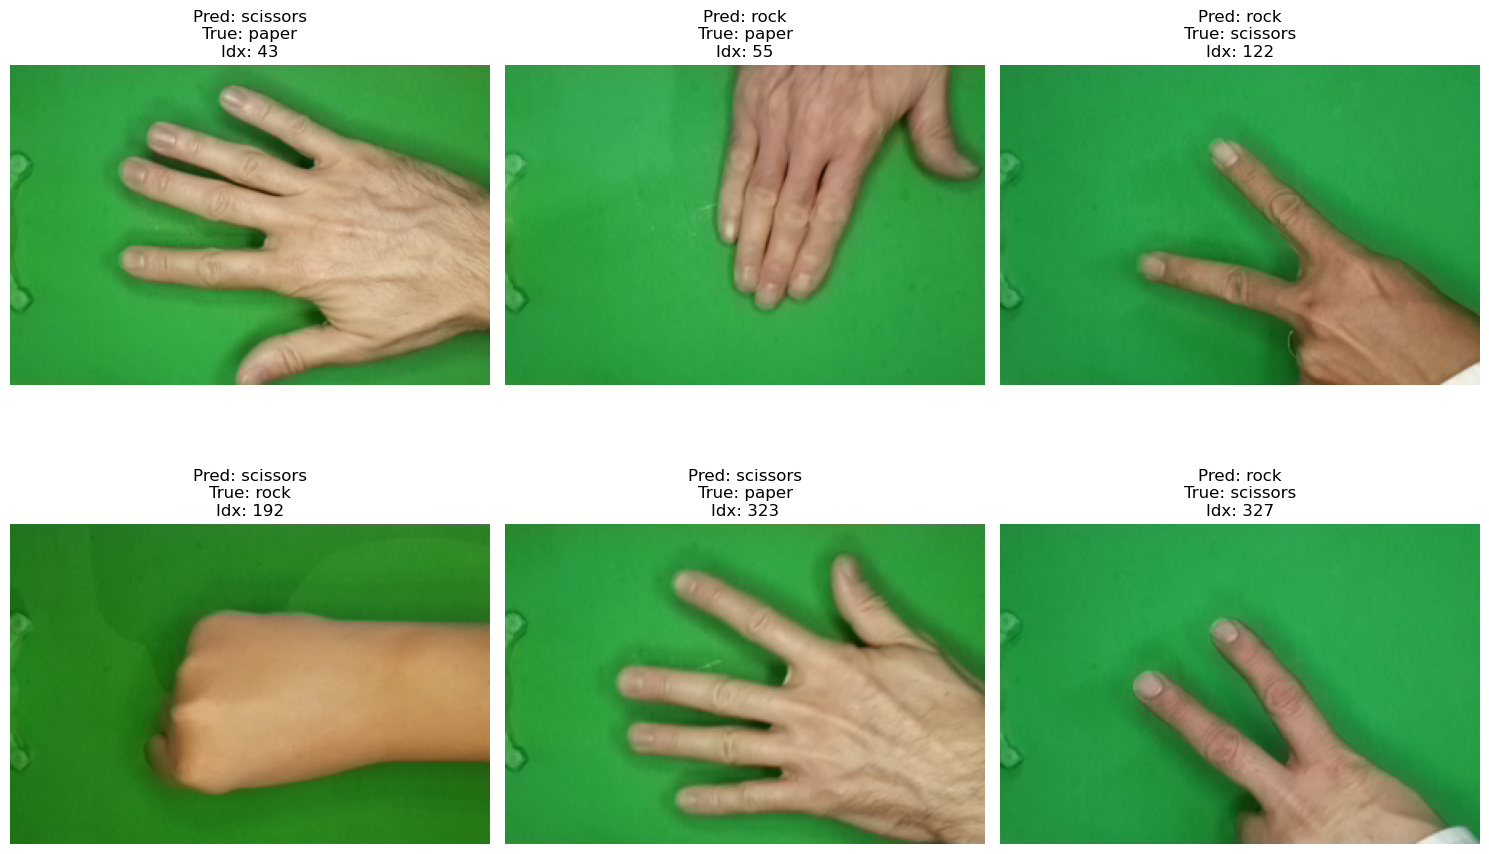

In [7]:
# only eval
from PIL import Image
import matplotlib.pyplot as plt
from src.evaluate import evaluate_model

train_loader, val_loader, test_loader, _ = create_dataloaders(RAW_DATA_DIR, batch_size=best_batch_size)

model = MicroResNet(num_classes=num_classes).to(device)
state_dict = torch.load(os.path.join(MODELS_DIR, "micro_resnet.pth"), map_location=device)
model.load_state_dict(state_dict)
criterion = nn.CrossEntropyLoss()

test_loss, all_preds, all_labels = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    device=device,
    class_mapping=class_mapping,
 )

idx_to_class = {idx: name for name, idx in class_mapping.items()}
test_file_paths = test_loader.dataset.file_paths
misclassified = [
    (i, test_file_paths[i], idx_to_class[int(pred)], idx_to_class[int(true)])
    for i, (pred, true) in enumerate(zip(all_preds, all_labels))
    if int(pred) != int(true)
]

print(f"\nEvaluation-only run completed. Test loss: {test_loss:.4f}")

if misclassified:
    print("\nMisclassified examples (prediction -> ground truth):")
    examples_to_show = misclassified[:6]
    cols = 3
    rows = (len(examples_to_show) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
    for ax, (i, img_path, pred_name, true_name) in zip(axes, examples_to_show):
        image = Image.open(img_path).convert("RGB")
        ax.imshow(image)
        ax.set_title(f"Pred: {pred_name}\nTrue: {true_name}\nIdx: {i}")
        ax.axis("off")
    for ax in axes[len(examples_to_show):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("\nNo misclassified examples found in the test set.")

In [ ]:
from src.models import MicroResNet
from src.webcam_utils import run_webcam_generalization_test

model = MicroResNet(num_classes=num_classes).to(device)
state_dict = torch.load(os.path.join(MODELS_DIR, "micro_resnet.pth"), map_location=device)
model.load_state_dict(state_dict)

# The function saves the captured images and a CSV summary under logs/webcam_generalization/.
webcam_results = run_webcam_generalization_test(
    model=model,
    device=device,
    class_mapping=class_mapping,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    samples_per_class=5,
    camera_index=0,
    save_dir=os.path.join(BASE_DIR, "logs", "webcam_generalization"),
)

webcam_results.head()
